In [1119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from scipy.stats import spearmanr


In [1120]:
bankfile=pd.read_csv('bank-additional-full.csv',sep=';')

In [1121]:
print(bankfile.info())
print(bankfile.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [1122]:
for col in bankfile.columns:
    print(f"\n=== {col} ===")
    print("Unique values (up to 20 shown):")
    print(bankfile[col].unique()[:20])

    print("\nValue counts (top 15 shown):")
    print(bankfile[col].value_counts().head(15))

    print("-" * 60)


=== age ===
Unique values (up to 20 shown):
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52]

Value counts (top 15 shown):
age
31    1947
32    1846
33    1833
36    1780
35    1759
34    1745
30    1714
37    1475
29    1453
39    1432
38    1407
41    1278
40    1161
42    1142
45    1103
Name: count, dtype: int64
------------------------------------------------------------

=== job ===
Unique values (up to 20 shown):
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

Value counts (top 15 shown):
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
------------------------------------------------------------

=== marital ==

<div dir = 'rtl'>
<h1>
حذف دیتاهای گمشده و یا پارامترهایی با نشت اطلاعات
</h1>
    
<div dir = 'rtl' >
<b>
حذف ستون duration
</b>
<br>
این ویژگی بعد از تماس مشخص می‌شود
و در مدل‌های واقعی قابل استفاده نمی‌باشد زیرا در صورت no بودن پاسخ به صورت قطعی می‌توان گفت که نتیجه اون ستون no  می‌باشد.
<br>
همچنین
در مدل‌های واقعی قبل از تماس قابل استفاده نیست.
<br>
<b>
حذف ستون default
</b>
<br>
تعداد کم مقدار yes در این ستون نسبت به تعداد داده ها نمی‌تواند در بدست اوردن یک ویژگی مهم برای پیشبینی تاثیرگذار باشد و بیشتر به عنوان ویژگی‌ای که باعث پیچیدگی محاسباتی بیشتر می‌شود می‌توان به ان نگاه کرد.
<br>
<b>
    در ادامه نیز به حذف داده ردیف هایی می‌پردازیم که در انها مقدار 'unknown' هست ولی خیلی درصد کمی را شامل می‌شود.

In [1123]:
bankfile=bankfile.drop(columns=['duration','default'])
bankfile = bankfile[
    (bankfile['job'] != 'unknown') & 
    (bankfile['marital'] != 'unknown') &
    (bankfile['loan'] != 'unknown' ) 
]

In [1124]:
bankfile[(bankfile['previous']!=0)]

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
24013,38,blue-collar,single,unknown,yes,no,telephone,oct,tue,1,999,1,failure,-0.1,93.798,-40.4,4.968,5195.8,no
24019,40,services,married,high.school,yes,no,telephone,oct,tue,1,999,1,failure,-0.1,93.798,-40.4,4.968,5195.8,yes
24076,36,admin.,married,university.degree,yes,no,telephone,nov,wed,1,999,1,failure,-0.1,93.200,-42.0,4.663,5195.8,no
24102,36,admin.,married,high.school,yes,no,telephone,nov,wed,1,999,1,failure,-0.1,93.200,-42.0,4.286,5195.8,yes
24108,37,admin.,married,university.degree,yes,no,telephone,nov,wed,1,6,1,success,-0.1,93.200,-42.0,4.286,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41174,62,retired,married,university.degree,yes,no,cellular,nov,thu,1,1,6,success,-1.1,94.767,-50.8,1.031,4963.6,yes
41175,34,student,single,unknown,yes,no,cellular,nov,thu,1,999,2,failure,-1.1,94.767,-50.8,1.031,4963.6,no
41178,62,retired,married,university.degree,no,no,cellular,nov,thu,2,6,3,success,-1.1,94.767,-50.8,1.031,4963.6,yes
41182,29,unemployed,single,basic.4y,yes,no,cellular,nov,fri,1,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,no


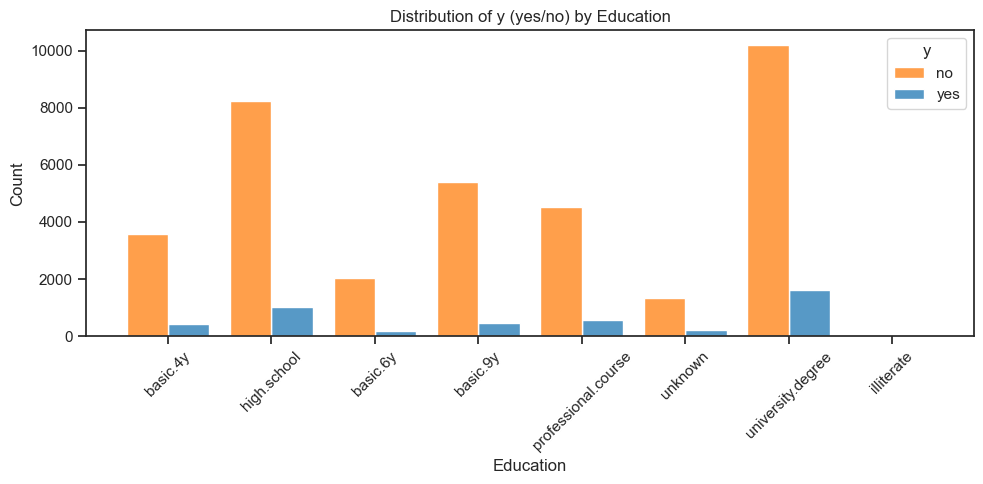

In [1125]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=bankfile,
    x='education',
    hue='y',
    multiple='dodge',
    shrink=0.8,
    stat='count',
    palette={'no':'#ff7f0e', 'yes':'#1f77b4'}   # تعیین رنگ‌ها
)

plt.xticks(rotation=45)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Distribution of y (yes/no) by Education')
plt.tight_layout()
plt.show()


In [1126]:
bankfile[(bankfile['education'] == 'unknown') & (bankfile['y'] == 'yes')].value_counts()


age  job          marital  education  housing  loan  contact    month  day_of_week  campaign  pdays  previous  poutcome     emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
31   student      single   unknown    yes      no    cellular   aug    thu          2         999    0         nonexistent  -1.7          94.027          -38.3          0.904      4991.6       yes    2
17   student      single   unknown    no       yes   cellular   oct    tue          1         2      2         success      -3.4          92.431          -26.9          0.742      5017.5       yes    1
47   blue-collar  married  unknown    no       no    telephone  may    tue          1         999    0         nonexistent   1.1          93.994          -36.4          4.856      5191.0       yes    1
48   blue-collar  married  unknown    no       no    cellular   aug    mon          3         999    0         nonexistent   1.4          93.444          -36.1          4.963      5228.1       yes 

<div dir='rtl'>
    بدلیل اینکه داده های unknown زیادی در ستون education وجود دارد ان را حذف نمی‌کنیم زیرا هم میانگین معنادار 'yes'در این ویژگی بیشتر است و هم تعداد انها زیاد می‌باشد و در اینده برای پیش بینی باقی مشتریان ممکن است با سطح تحصیلات نامعلومی برای پیش‌بینی وارد داده‌ها شوند
    <br>
    در ادامه می‌توان ان را یک کلاس جدا در نظر گرفت یا به داده هایی با نتیجه مشابه unknown مپ کرد که روش اول راحت‌تر می‌باشد. 

In [1127]:
bankfile['y']=bankfile['y'].map({'yes':1,'no':0})
x_bank_data=bankfile.drop('y',axis=1)
y_bank_data=bankfile['y']

x_bank_data['has_prev_contact'] = (x_bank_data['pdays'] != 999).astype(int)
x_bank_data['pdays_real'] = x_bank_data['pdays'].replace(999, np.nan)

x_bank_data = pd.get_dummies(x_bank_data, drop_first=True)



In [1150]:
x_train, x_test, y_train, y_test = train_test_split(
    x_bank_data, y_bank_data, test_size=0.2, random_state=42
)
train_df = x_train.copy()
train_df['y'] = y_train.values


<div dir='rtl'>
    بهتره برای اینکه نشت اطلاعات نداشته باشیم از این داده ها ابتدا داده ها رو برای train & test  جدا کنیم چون در غیر این صورت داده های تست که باید تنها در مرحله اخر در مدل وارد شوند در اموزش دارند استفاده می‌شوند.

In [1151]:
num_cols = [
'age','campaign','pdays','previous',
'emp.var.rate','cons.price.idx',
'cons.conf.idx','euribor3m','nr.employed'
]

scaler = StandardScaler()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])


<div dir = 'rtl'>
<h2>
 استانداردسازی داده‌ها 
</h2>
این مدل مقیاس‌بندی با فرض توزیع گوسی (نرمال)، داده‌ها را به گونه‌ای تغییر می‌دهد که میانگین آن‌ها برابر با 0 و انحراف معیار آن‌ها برابر با 1 شود.
$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$
$$z = \frac{x - \mu}{\sigma}$$
</div>

### 2.data_visualization
<div dir='rtl'>
 نمودار‌های درصد موفقیت برحسب معیار های اقتصادی و شخصی افراد

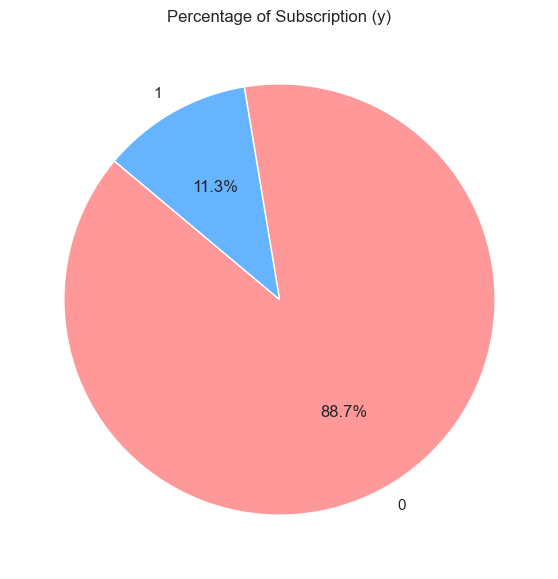

In [1152]:
counts = bankfile['y'].value_counts()

# ۲. رسم نمودار
plt.figure(figsize=(7, 7))
plt.pie(counts, 
        labels=counts.index,   # برچسب‌ها (yes و no)
        autopct='%1.1f%%',     # نمایش درصد روی نمودار
        startangle=140,        # زاویه شروع برای ظاهر بهتر
        colors=['#ff9999','#66b3ff']) # تعیین رنگ‌های دلخواه

plt.title('Percentage of Subscription (y)')
plt.show()

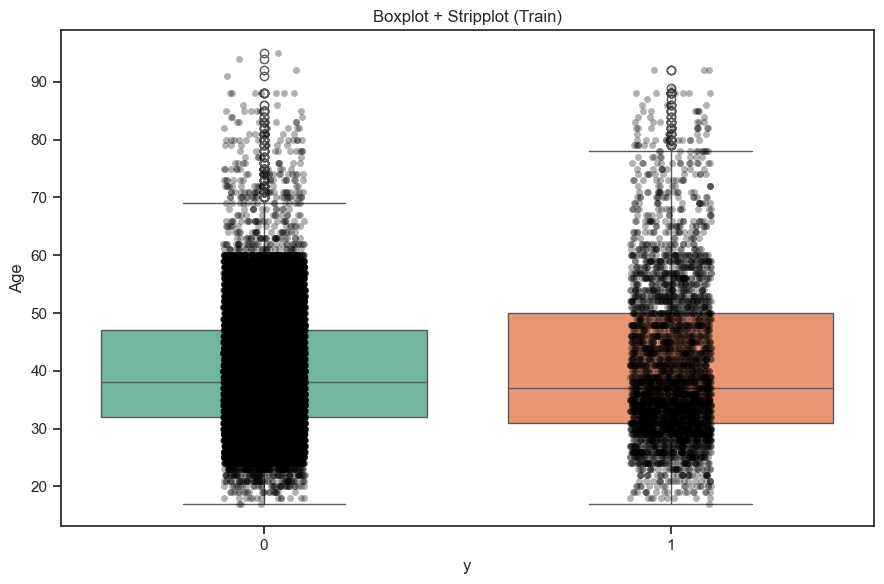

In [1153]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=train_df, x='y', y='age', 
            palette='Set2', 
            hue='y',   
            legend=False)  
sns.stripplot(data=train_df, x='y', y='age', color='black', alpha=0.3)

plt.title('Boxplot + Stripplot (Train)')
plt.xlabel('y')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


<div dir='rtl'>
نمودار‌های boxplot بیشترین رنج سنی‌ای را نشان می‌دهند که در این فرایند شرکت داشته‌اند.
    <br>
    اما در مقادیر outlier می‌توان مشاهده نمود که درصد احتمال موفقیت بسیار بالا می‌رود.

In [1154]:
def plot_subscription_vs_feature(df, feature, bins=200):
    
    temp = df[[feature, 'y']].copy()
    temp['bin'] = pd.qcut(temp[feature], bins, duplicates='drop')
    grouped = temp.groupby('bin', observed=False).agg({
        feature: 'mean',
        'y': 'mean'
    }).reset_index()
    
    fig = px.scatter(
        grouped,
        x=feature,
        y='y',
        trendline='ols',
        title=f'Subscription Rate vs {feature} (Train Set)',
        labels={feature: feature, 'y': 'Subscription Rate'},
        color='y'
    )
    
    fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')))
    fig.show()

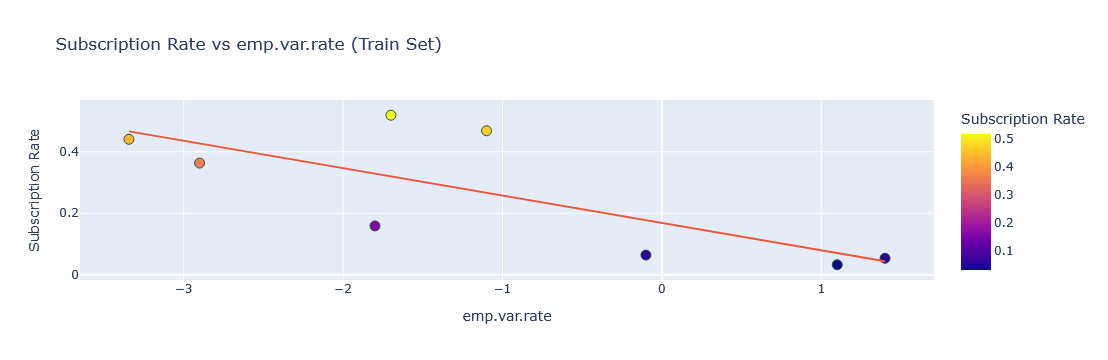

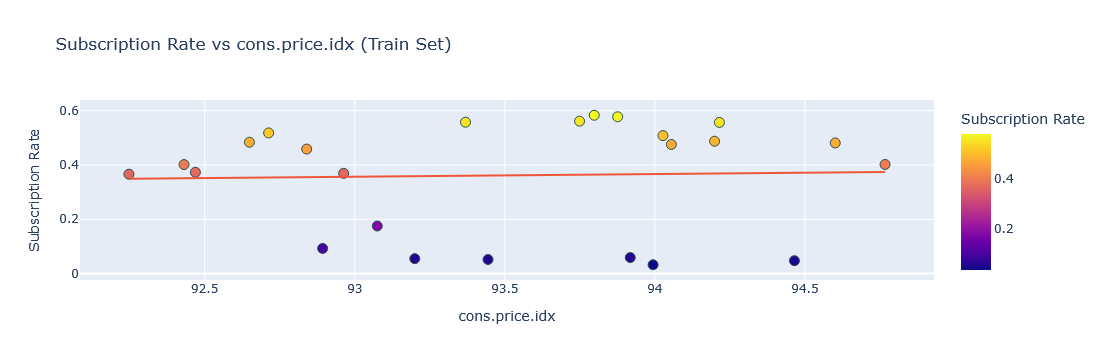

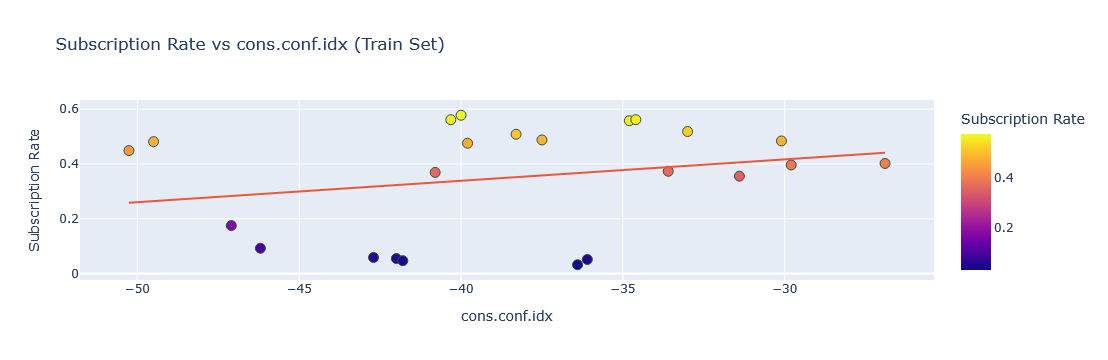

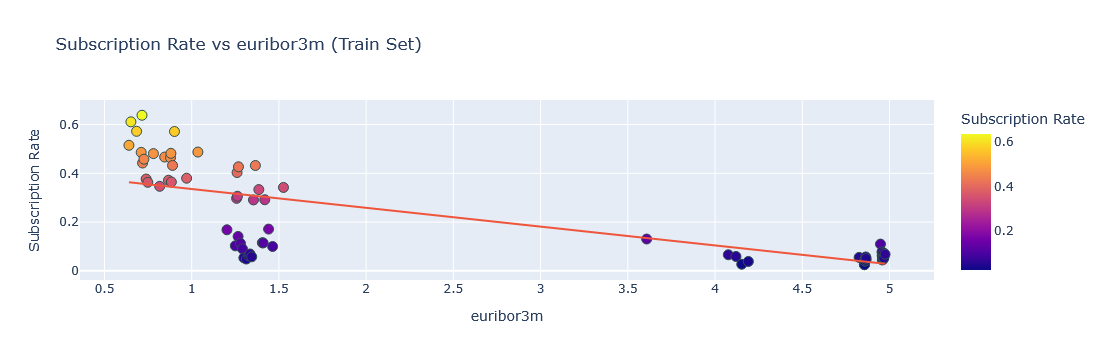

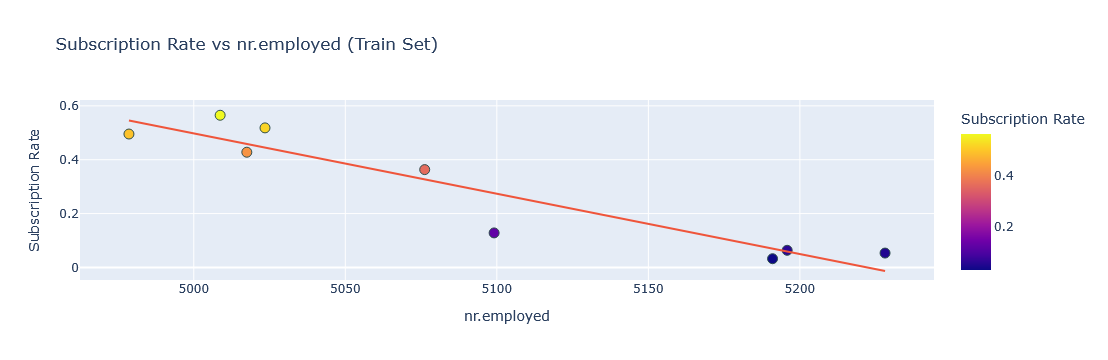

In [1155]:
economic_features = [
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

for feature in economic_features:
    plot_subscription_vs_feature(train_df, feature, bins=200)


<div dir ='rtl'>
    ویژگی‌های 'nr.employed' و 'euribor3m' و تا حدی  'emp.var.rate' می‌توانند با یک رگرسیون خطی در پیش‌بینی نتیجه مفید باشند  اما مورد سوم بدلیل اینکه تعداد مقادیر unique کمی را شامل می‌شوند به طور قطع نمی‌‌‌‌‌توان نظر داد. <br>
    دو ویژگی دیگر بیشتر قابل استفاده در رگرسیون خطی نمی‌باشند.

In [1156]:
df_yes = train_df[train_df['y'] == 1]
df_no = train_df[train_df['y'] == 0]
df_no_sample = df_no.sample(n=len(df_yes), random_state=42)
viz_df = pd.concat([df_yes, df_no_sample])


<div dir = 'rtl'>
    داده ها را نرمالایز می‌کنیم تا نمایش بهتری داشته باشند.

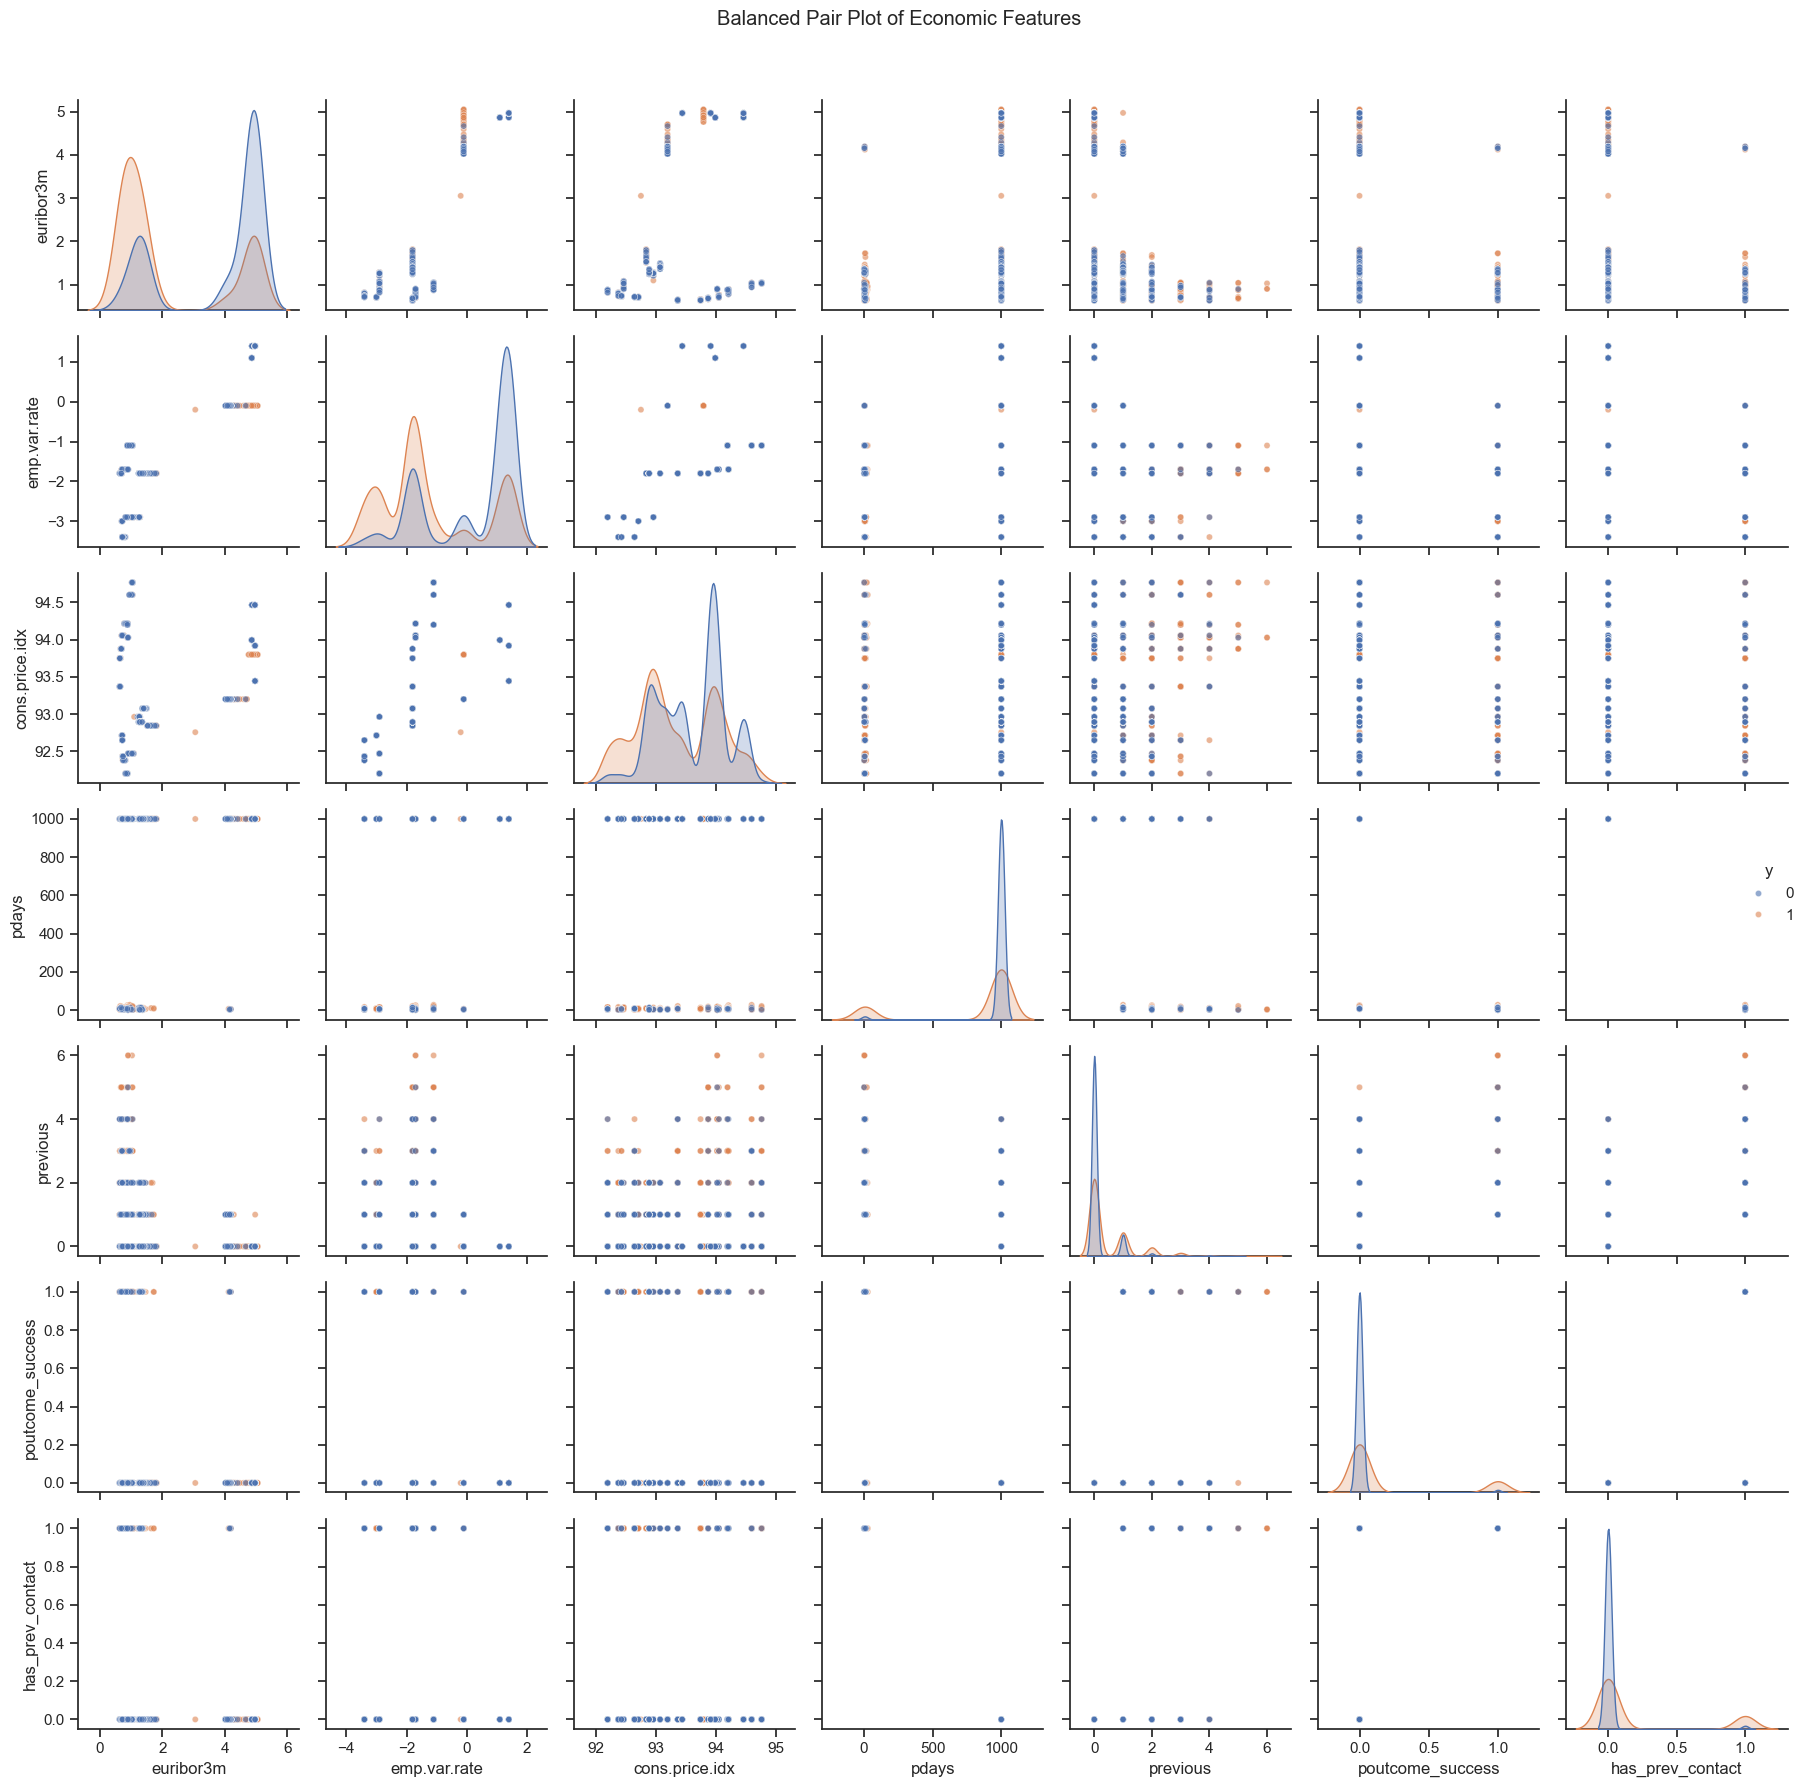

In [1157]:
features = ['euribor3m', 'emp.var.rate', 'cons.price.idx', 'pdays','previous','poutcome_success','has_prev_contact']

sns.set(style="ticks")

pairplot = sns.pairplot(
    data=viz_df,
    vars=features,
    hue='y',
    diag_kind='kde',
    plot_kws={'alpha':0.6, 's':20}
)

pairplot.fig.suptitle("Balanced Pair Plot of Economic Features", y=1.02)

plt.tight_layout()


In [1158]:
corr_matrix = train_df.select_dtypes(include='number').corr(method='pearson')
print(corr_matrix)


                       age  campaign     pdays  previous  emp.var.rate  \
age               1.000000  0.004427 -0.031587  0.026890     -0.002214   
campaign          0.004427  1.000000  0.053730 -0.081466      0.151762   
pdays            -0.031587  0.053730  1.000000 -0.582112      0.270898   
previous          0.026890 -0.081466 -0.582112  1.000000     -0.422114   
emp.var.rate     -0.002214  0.151762  0.270898 -0.422114      1.000000   
cons.price.idx    0.002619  0.127199  0.082103 -0.204537      0.776026   
cons.conf.idx     0.122870 -0.015258 -0.093679 -0.048777      0.196205   
euribor3m         0.007937  0.136078  0.295719 -0.455654      0.972191   
nr.employed      -0.021170  0.145502  0.369945 -0.502603      0.906640   
has_prev_contact  0.031530 -0.053718 -0.999993  0.582077     -0.270849   
pdays_real       -0.053669  0.035333  1.000000 -0.028958      0.133409   
y                 0.033837 -0.065058 -0.320342  0.225619     -0.297586   

                  cons.price.idx  con

<div dir='rtl'>
    پس از نرمالایز کردن، داده‌ها را با  pairplot به صورت شهودی بررسی می‌کنیم و همچنین ماتریس کوواریانس ان را بدست می‌اوریم تا همبستگی آنها را بسنجیم.
    <br>
داده های ستون های 'pdays' & 'poutcome_success' & 'has_prev_contact' تقریبا همبستگی خوبی را نشان می‌دهد.
می‌توان یک ستون را حذف کرد
و همچینین ستون‌های 'poutcome_nonexistent'& 'previous' با یکدیگر با 90 درصد همبستگی، همبسته اند. 
    این همبستگی در pairplot قبلی نیز قابل مشاهده می‌باشد.

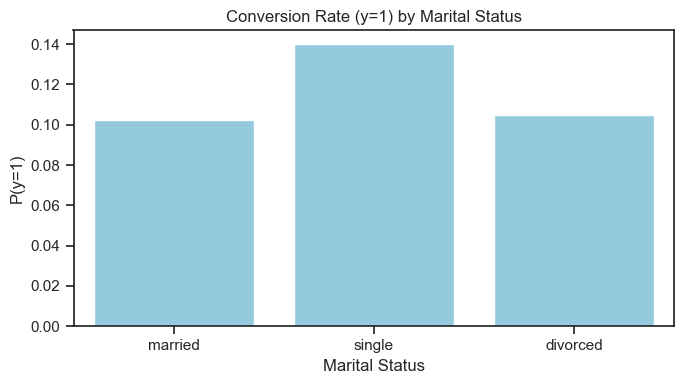

In [1159]:
if 'marital_divorced' not in train_df.columns:
    train_df['marital_divorced'] = (
        (train_df['marital_married'] == 0) & (train_df['marital_single'] == 0)
    ).astype(int)
marital_cols = ['marital_married', 'marital_single', 'marital_divorced']

plot_df = train_df[marital_cols + ['y']].copy()

summary = []

plt.figure(figsize=(7,4))
sns.barplot(
    x=summary_df.index,
    y=summary_df['y_1'],
    color='skyblue'
)
plt.title('Conversion Rate (y=1) by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('P(y=1)')
plt.tight_layout()
plt.show()


ماه‌هایی که ستونشان حذف شده است: ['jan', 'feb']


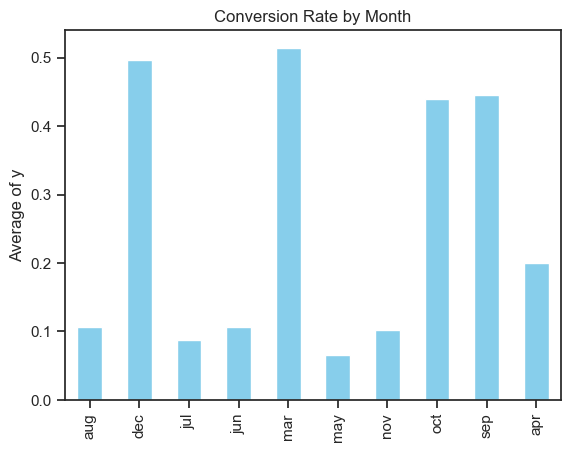

In [1160]:
all_month_cols = [
    'month_aug', 'month_dec', 'month_jul', 'month_jun', 
    'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep'
]

train_df['month_apr'] = (train_df[all_month_cols].sum(axis=1) == 0).astype(int)

all_months = all_month_cols + ['month_apr']
expected_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

missing = [m for m in expected_months if f'month_{m}' not in train_df.columns]
print(f"ماه‌هایی که ستونشان حذف شده است: {missing}")
monthly_conv = {}
for m in all_months:
    monthly_conv[m.replace('month_', '')] = train_df[train_df[m] == 1]['y'].mean()

pd.Series(monthly_conv).plot(kind='bar', color='skyblue')
plt.title('Conversion Rate by Month')
plt.ylabel('Average of y')
plt.show()

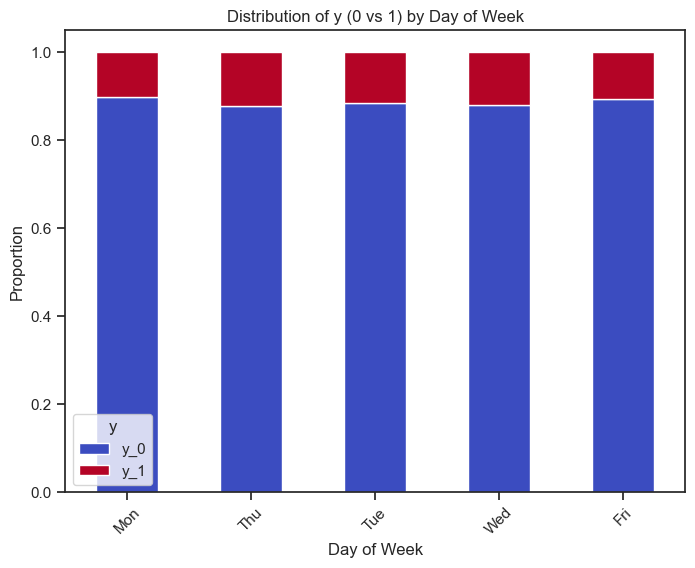

In [1161]:
days = [
    'day_of_week_mon',
    'day_of_week_thu',
    'day_of_week_tue',
    'day_of_week_wed'
]

train_df['day_of_week_fri'] = (train_df[days].sum(axis=1) == 0).astype(int)

all_days = days + ['day_of_week_fri']
data = []
for d in all_days:
    subset = train_df[train_df[d] == 1]
    counts = subset['y'].value_counts(normalize=True)
    data.append({
        'day': d.replace('day_of_week_', '').capitalize(),
        'y_0': counts.get(0, 0),
        'y_1': counts.get(1, 0)
    })

plot_df = pd.DataFrame(data).set_index('day')

plot_df[['y_0', 'y_1']].plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    colormap='coolwarm'
)

plt.title('Distribution of y (0 vs 1) by Day of Week')
plt.ylabel('Proportion')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.legend(title='y')
plt.show()

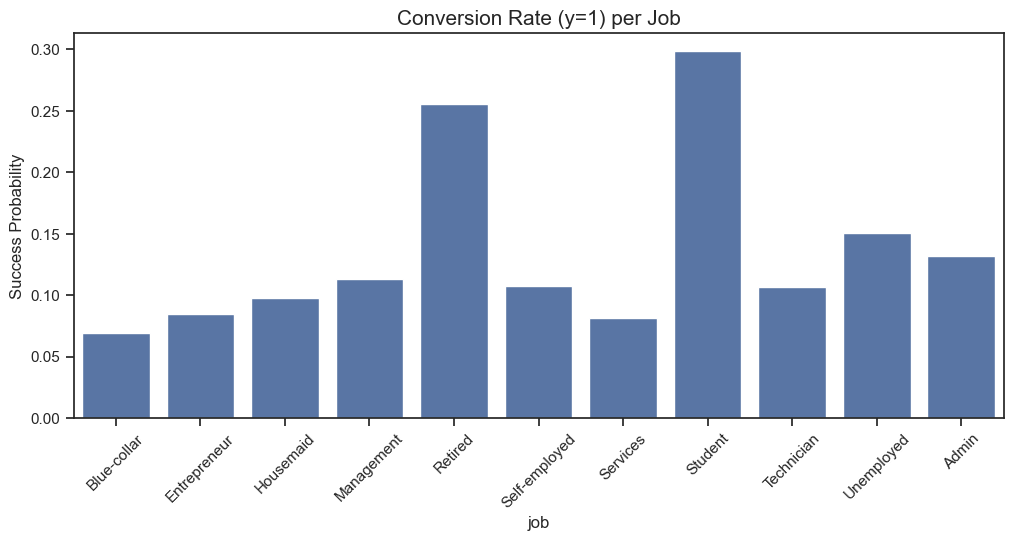

In [1162]:
job_cols = [
    'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 
    'job_management', 'job_retired', 'job_self-employed', 
    'job_services', 'job_student', 'job_technician', 'job_unemployed'
]

train_df['job_admin'] = (train_df[job_cols].sum(axis=1) == 0).astype(int)

all_job_types = job_cols + ['job_admin']

job_data = []
for j in all_job_types:
    subset = train_df[train_df[j] == 1]
    if len(subset) > 0:
        counts = subset['y'].value_counts(normalize=True)
        job_data.append({
            'job': j.replace('job_', '').capitalize(),
            'y_0': counts.get(0, 0),
            'y_1': counts.get(1, 0)
        })

plot_jobs_df = pd.DataFrame(job_data).set_index('job')


plt.figure(figsize=(12, 5))
sns.barplot(x=plot_jobs_df.index, y=plot_jobs_df['y_1'])
plt.title('Conversion Rate (y=1) per Job', fontsize=15)
plt.ylabel('Success Probability')
plt.xticks(rotation=45)
plt.show()


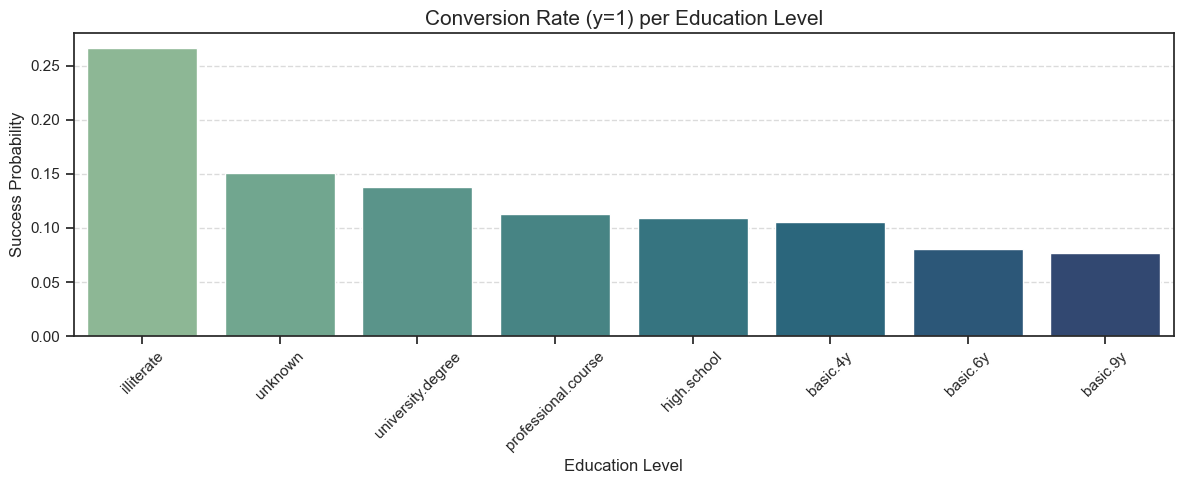

In [1163]:
edu_cols = [
    'education_basic.6y', 'education_basic.9y', 'education_high.school', 
    'education_illiterate', 'education_professional.course', 
    'education_university.degree', 'education_unknown'
]
train_df['education_basic.4y'] = (train_df[edu_cols].sum(axis=1) == 0).astype(int)
all_edu_types = edu_cols + ['education_basic.4y']

edu_data = []
for e in all_edu_types:
    subset = train_df[train_df[e] == 1]
    if len(subset) > 0:
        counts = subset['y'].value_counts(normalize=True)
        edu_data.append({
            'education': e.replace('education_', ''),
            'y_0': counts.get(0, 0),
            'y_1': counts.get(1, 0)
        })

plot_edu_df = pd.DataFrame(edu_data).set_index('education')

plt.figure(figsize=(12, 5))

sorted_edu = plot_edu_df.sort_values(by='y_1', ascending=False)

sns.barplot(
    x=sorted_edu.index, 
    y=sorted_edu['y_1'], 
    hue=sorted_edu.index,   
    palette='crest', 
    legend=False           
)

plt.title('Conversion Rate (y=1) per Education Level', fontsize=15)
plt.ylabel('Success Probability')
plt.xlabel('Education Level')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()



<div dir='rtl'>
    در نمودار های بالا بررسی می‌کنیم که ایا ویژگی‌های غیر عددی در نهایت روی ننتیجه تاثیر دارند یا نمودار یکنواخت می‌باشد.
    <br>
    نمودار Stacked Bar این داده‌ها نشان‌دهنده این می‌باشد که در ماه‌های september , march , october , december احتمال بله گفتن خیلی بیشتر می‌باشد و تقریبا در این ماه‌ها بایکدیگر یکسان می‌باشند.
تقریبا برای همه روزها یکسان می‌باشد.
    می‌توان برای ادامه از این متغیر ها صرف نظر کرد.
    <br>
    برای شغل و روز های هفته هم این نمودارها را به صورت مشابه می‌بینیم و مشاهده می‌شود که روز بر روی نتیجه تاثیری ندارد
    <br>
    اما برخی مشاغل و درجه‌های تحصیلی در احتمال افتتاح حساب باعث ایجاد تفاوت می‌شوند.

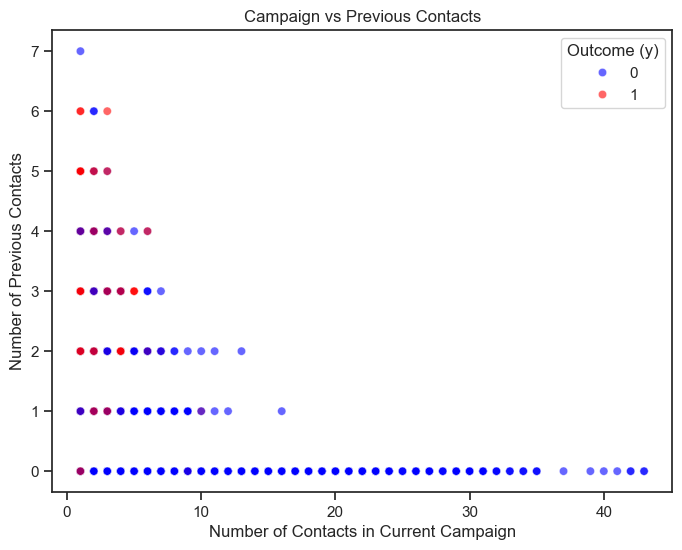

In [1164]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=train_df,
    x='campaign',
    y='previous',
    hue='y',
    palette={0:'blue', 1:'red'},
    alpha=0.6
)

plt.title('Campaign vs Previous Contacts')
plt.xlabel('Number of Contacts in Current Campaign')
plt.ylabel('Number of Previous Contacts')
plt.legend(title='Outcome (y)')
plt.show()



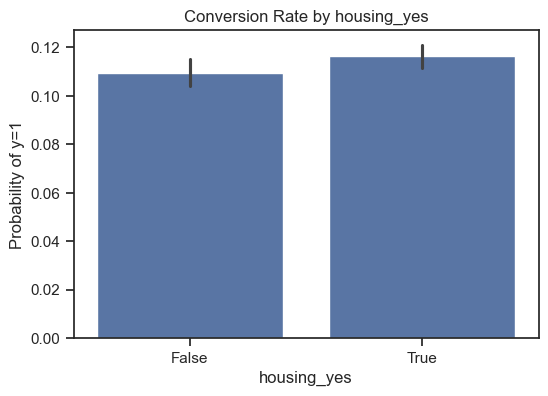

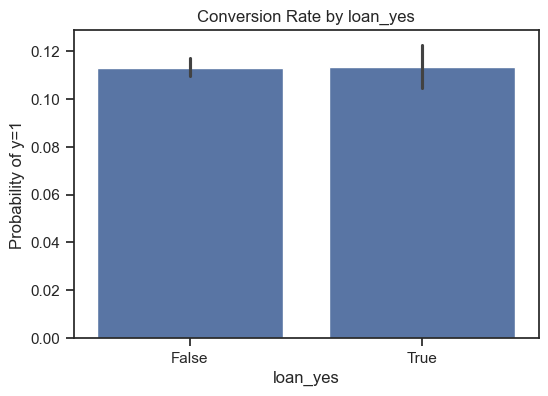

In [1165]:
binary_cols = ['housing_yes', 'loan_yes']

for col in binary_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='y', data=train_df)
    plt.title(f'Conversion Rate by {col}')
    plt.ylabel('Probability of y=1')
    plt.show()


<div dir = 'rtl'>
در موارد بالا نشان داده شده که دو مورد housing , loan در نتیجه نهایی فرق زیادی را نشان نمی‌دهند.
    

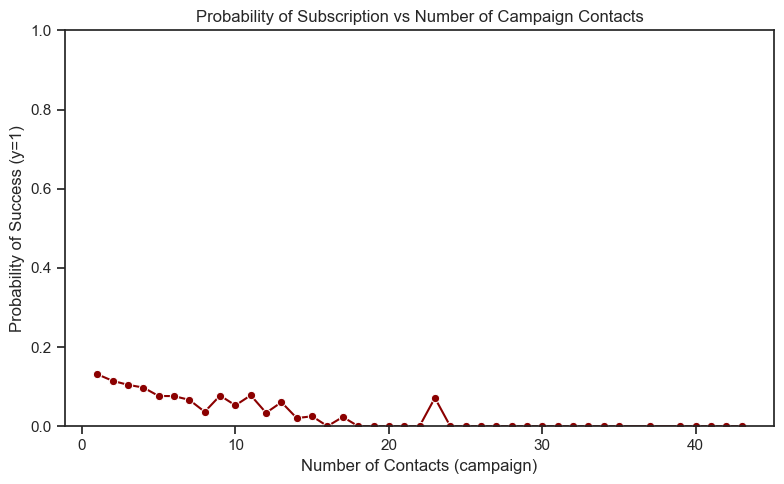

In [1166]:

campaign_success = train_df.groupby('campaign')['y'].mean()

plt.figure(figsize=(8,5))
sns.lineplot(
    x=campaign_success.index,
    y=campaign_success.values,
    marker='o',
    color='darkred'
)

plt.title('Probability of Subscription vs Number of Campaign Contacts')
plt.xlabel('Number of Contacts (campaign)')
plt.ylabel('Probability of Success (y=1)')
plt.ylim(0,1)

plt.tight_layout()
plt.show()


<div dir='rtl'>
    از نمودار بالا برداشت می‌شود اگر قرار باشد مشتری راضی شود که حساب باز کند با همان تماس های اولیه حسابش را افتتاح می‌کند و در صورت رسیدن تعداد تماس ها به یک مقداری می‌توان پی برد که حساب بلندمدت با احتمال خیلی کمی افتتاح می‌شود. 

## 3.featuring data

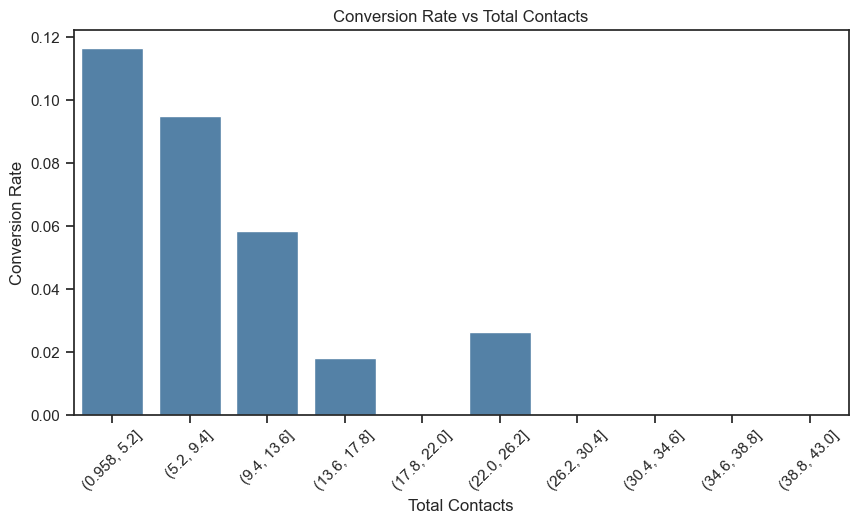

In [1167]:
train_df['total_contacts'] = train_df['campaign'] + train_df['previous']
train_df['total_contacts_bin'] = pd.cut(train_df['total_contacts'], bins=10)

signal = train_df.groupby('total_contacts_bin', observed=True)['y'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=signal, x='total_contacts_bin', y='y', color='steelblue')
plt.xticks(rotation=45)
plt.title('Conversion Rate vs Total Contacts')
plt.ylabel('Conversion Rate')
plt.xlabel('Total Contacts')
plt.show()


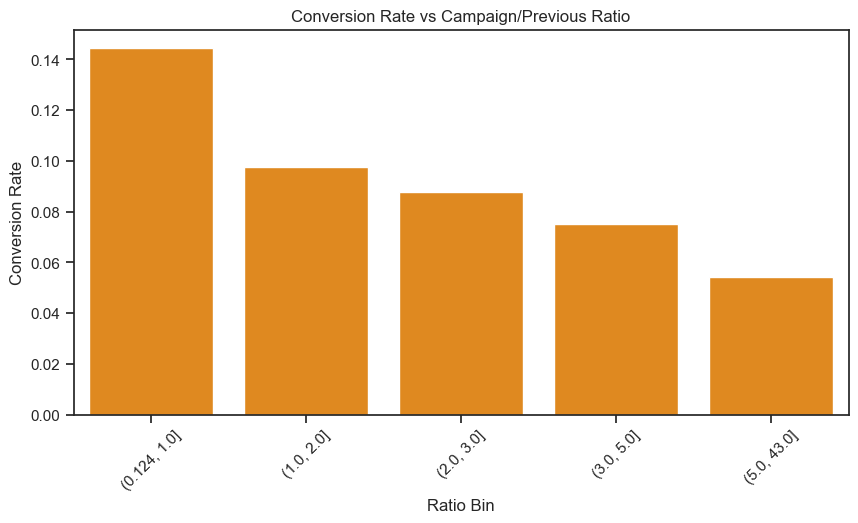

In [1168]:
train_df['campaign_to_previous_ratio'] = train_df['campaign'] / (train_df['previous'] + 1)
train_df['ratio_bin'] = pd.qcut(train_df['campaign_to_previous_ratio'], q=10, duplicates='drop')

signal = train_df.groupby('ratio_bin', observed=True)['y'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=signal, x='ratio_bin', y='y', color='darkorange')

plt.xticks(rotation=45)
plt.title('Conversion Rate vs Campaign/Previous Ratio')
plt.ylabel('Conversion Rate')
plt.xlabel('Ratio Bin')
plt.show()


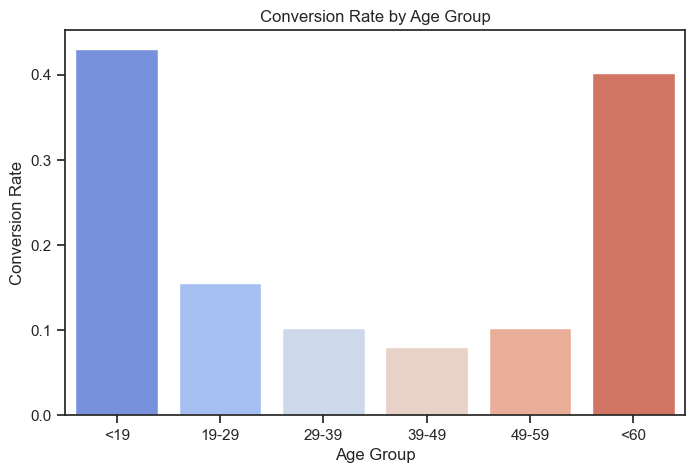

In [1169]:
train_df['age_group'] = pd.cut(
    bankfile['age'],
    bins=[0, 19, 29, 39, 49, 59,100],
    labels=['<19', '19-29', '29-39', '39-49', '49-59','<60']
)
signal = train_df.groupby('age_group', observed=True)['y'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=signal,
    x='age_group',
    y='y',
    hue='age_group', 
    palette='coolwarm',
    legend=False
)
plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate')
plt.show()


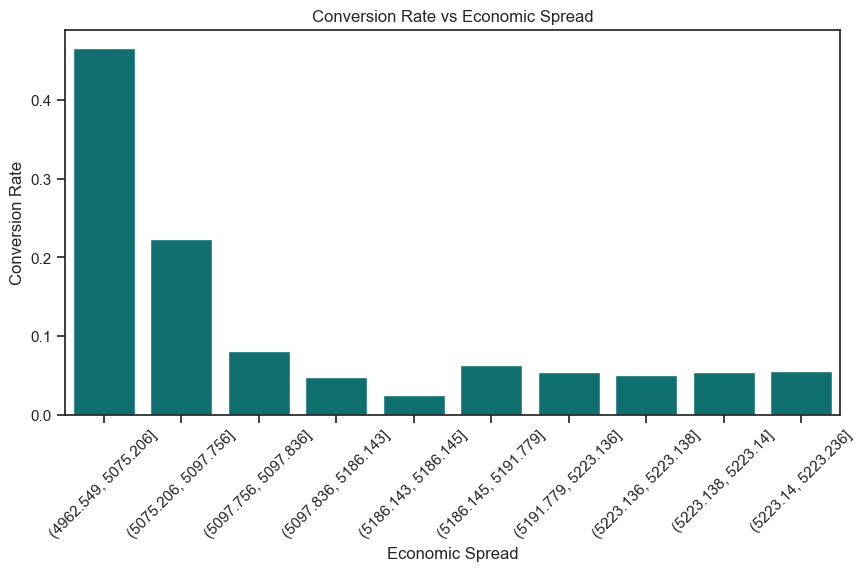

In [1170]:
train_df['economic_spread'] = train_df['nr.employed'] - train_df['euribor3m']
train_df['economic_spread_bin'] = pd.qcut(train_df['economic_spread'], q=10, duplicates='drop')

signal = train_df.groupby('economic_spread_bin',observed=True)['y'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=signal, x='economic_spread_bin', y='y', color='teal')

plt.xticks(rotation=45)
plt.title('Conversion Rate vs Economic Spread')
plt.xlabel('Economic Spread')
plt.ylabel('Conversion Rate')

plt.show()


In [1171]:
train_df['employment_rate_change'] = train_df['emp.var.rate'] * train_df['euribor3m']

train_df['consumer_sentiment_economic_idx'] = (
    train_df['cons.conf.idx'] - train_df['cons.price.idx']
)

train_df['economic_conditions_proxy'] = (
    train_df['euribor3m'] * train_df['cons.price.idx']
)

train_df['inflation_to_employment_ratio'] = (
    train_df['cons.price.idx'] / train_df['nr.employed']
)

train_df['sentiment_adjusted_employment'] = (
    train_df['nr.employed'] * train_df['cons.conf.idx']
)

train_df['real_activity_index'] = (
    train_df['emp.var.rate'] * train_df['cons.price.idx']
)

train_df['labor_market_pressure'] = (
    train_df['nr.employed'] / (train_df['euribor3m'] + 1)
)


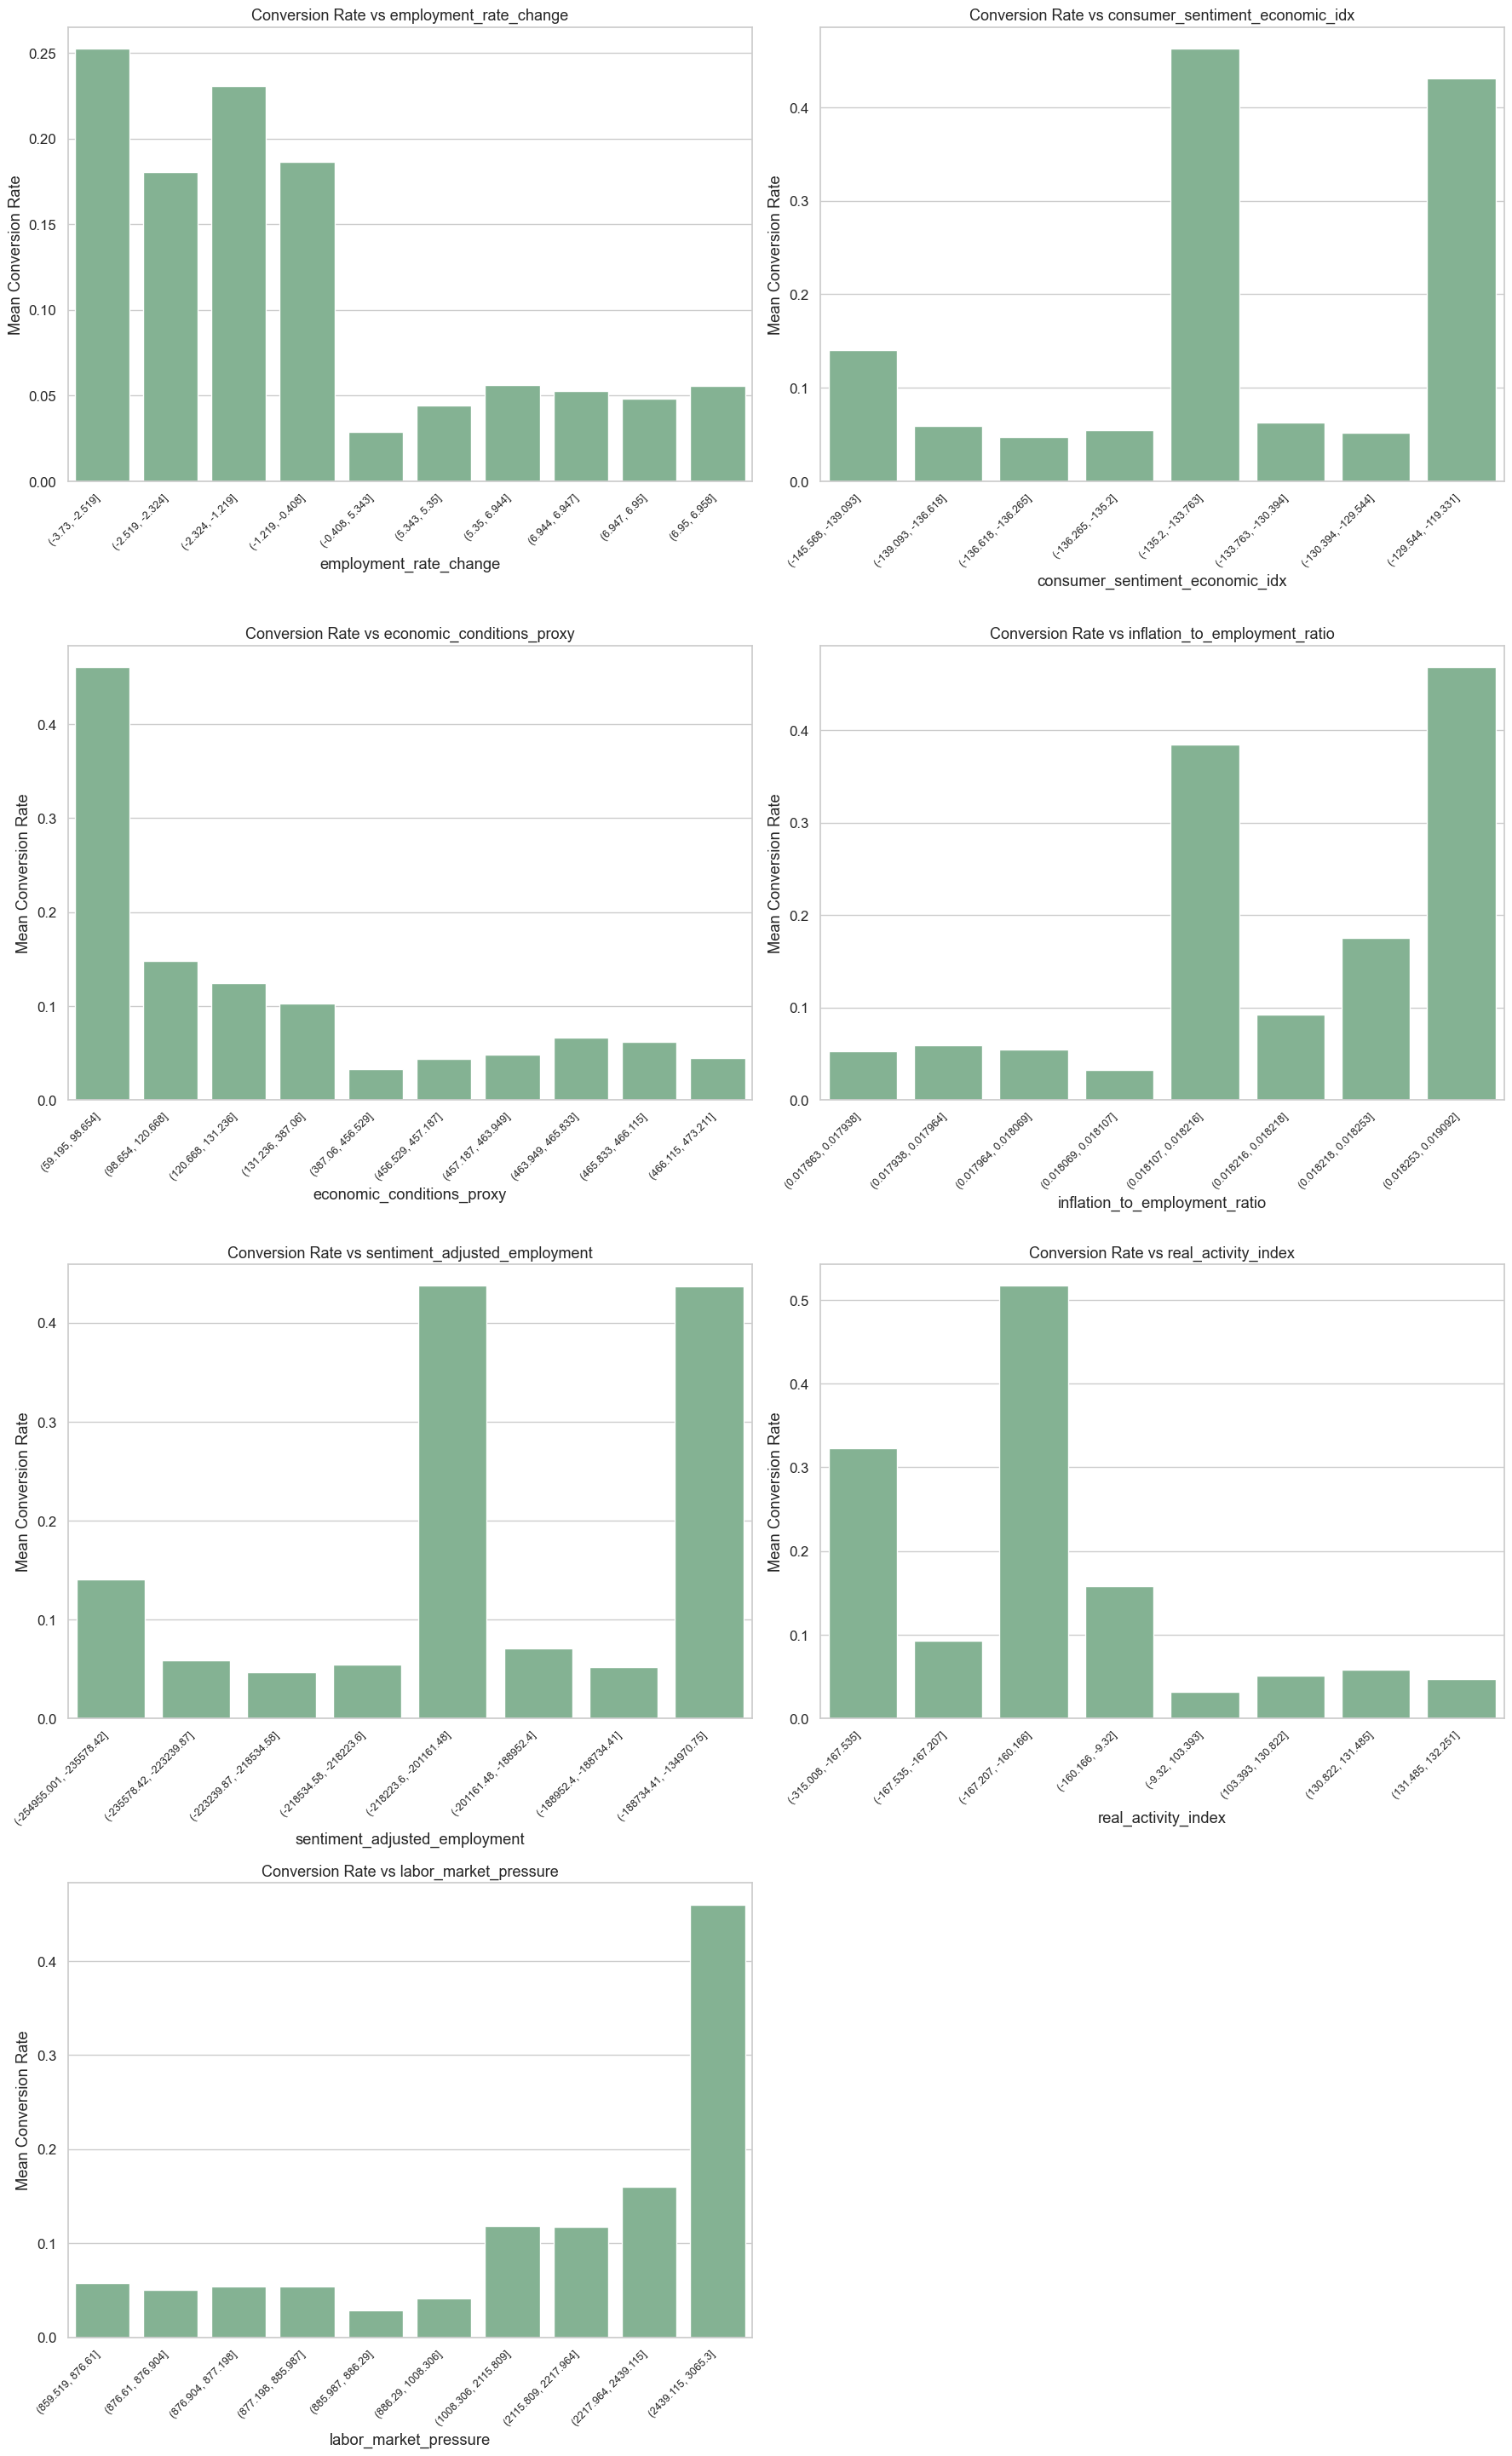

In [1172]:
sns.set(style="whitegrid", palette="crest", font_scale=1.1)
new_features = [
     'employment_rate_change',
    'consumer_sentiment_economic_idx', 'economic_conditions_proxy',
    'inflation_to_employment_ratio', 'sentiment_adjusted_employment',
    'real_activity_index', 
     'labor_market_pressure'
]
plt.figure(figsize=(18, 35))

for i, feature in enumerate(new_features, 1):
    plt.subplot(5, 2, i)
    
    bins = pd.qcut(train_df[feature], q=10, duplicates='drop')
    
    plot_data = train_df.groupby(bins,observed=True)['y'].mean().reset_index()
    plot_data['x_labels'] = plot_data[feature].astype(str)
    
    sns.barplot(x='x_labels', y='y', data=plot_data)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.title(f'Conversion Rate vs {feature}', fontsize=13)
    plt.xlabel(feature)
    plt.ylabel('Mean Conversion Rate')

plt.tight_layout()
plt.show()

<div dir = 'rtl'>
    تعدادی داده جدید با توابع ساده ریاضیاتی درست کردیم که تا احتمال وقوع yes در نتیجه را بالاتر ببریم و بجای دیتاهای خام شانس تفکیک را در اموزش بیشتر کنیم.  
    <br>
    درضمن در نمودار بالا توزیع توابع دیگری هم بود که برای شباهت و وجود عناصر مشابه در  تولید انها حذف گردید.

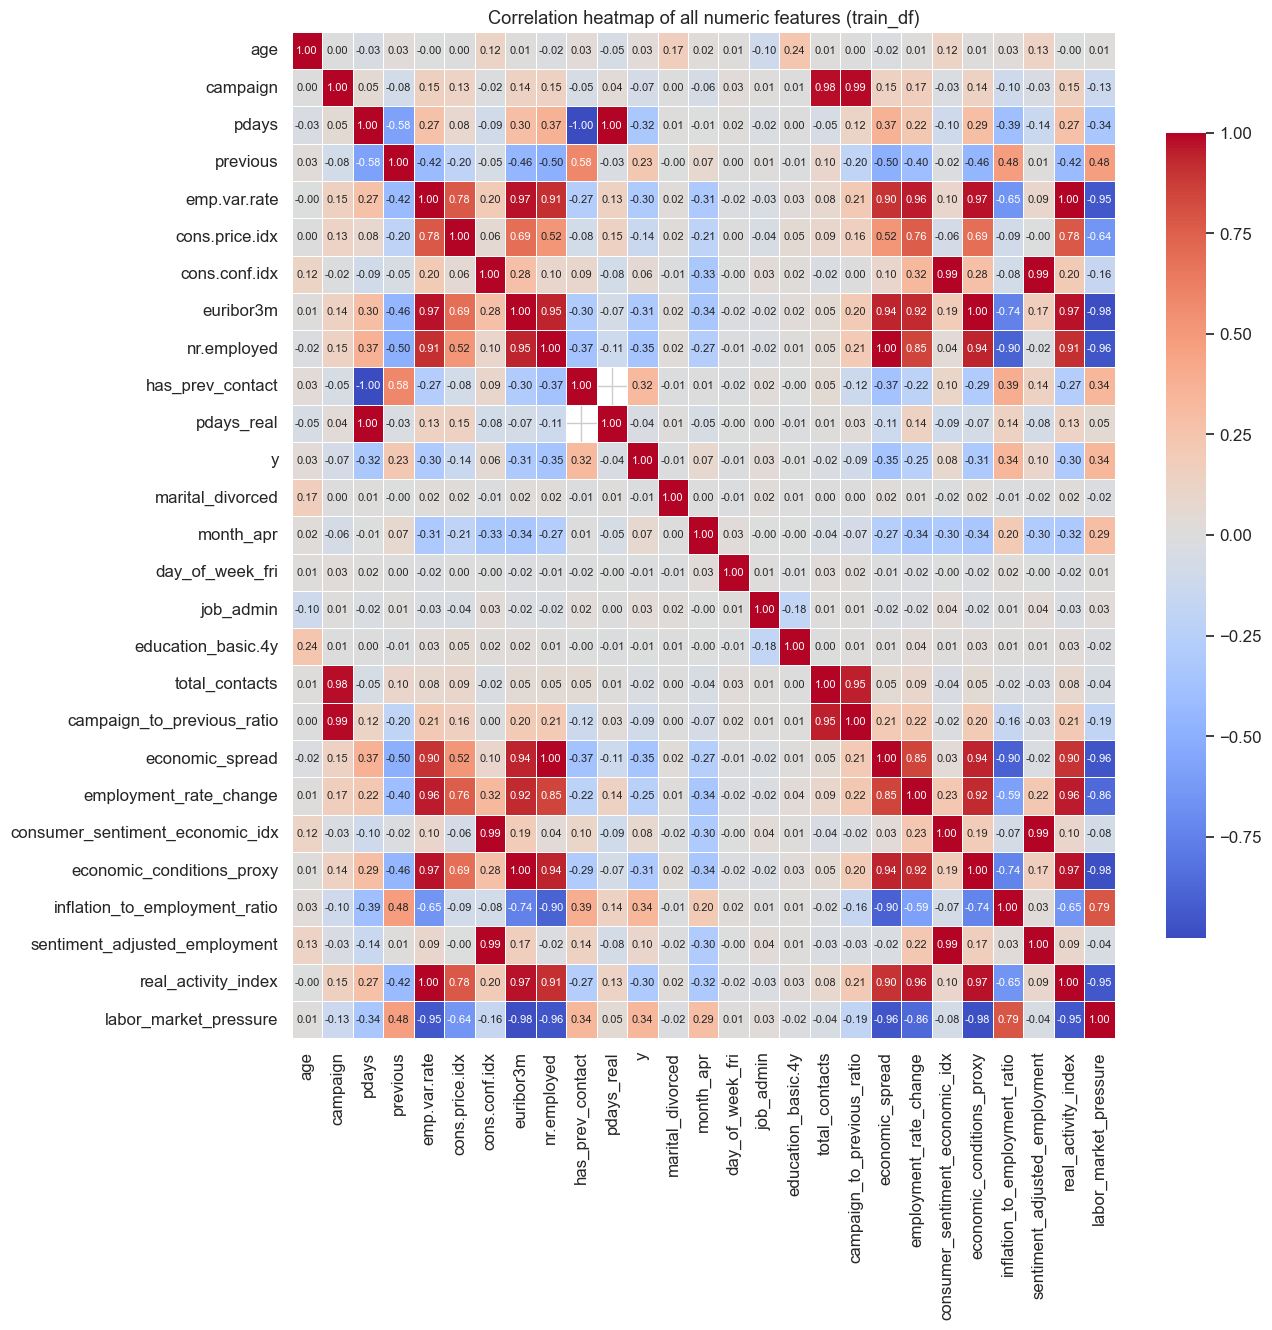

In [1173]:
num_df = train_df.select_dtypes(include=['number'])

num_df = num_df.loc[:, num_df.var() > 0]
corr = num_df.corr()
plt.figure(figsize=(max(12, 0.5 * len(num_df.columns)), max(10, 0.5 * len(num_df.columns))))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title("Correlation heatmap of all numeric features (train_df)")
plt.tight_layout()
plt.show()

In [1174]:
cols_to_drop = ['campaign','age','pdays','cons.price.idx','cons.conf.idx']+['emp.var.rate','euribor3m','nr.employed','economic_conditions_proxy']

train_df = train_df.drop(columns=cols_to_drop)
train_df=train_df.drop(columns=['poutcome_nonexistent','poutcome_success','economic_spread_bin'])
train_df=train_df.drop(columns=all_days)
train_df=train_df.drop(columns=binary_cols)


<div dir='rtl'>
<h2>
    <b>
    بدست اوردن همبستگی متقابل ویژگی‌های عددی و حذف داده‌های اضافی 
</h2>
    </b>
    <br>
    داده‌های خامی را که براساس انها ستون های جدید ایجاد کرده بودیم را حذف و توابعی را که همبستگی انها بیشتر از 0.83 می‌باشد نیز حذف می‌کنیم تا باعث پیچیدگی نشود.

Detected task: binary

Top 10 Ranked Features (including engineered features):
metric                                 MI  strength
feature                                            
labor_market_pressure            0.079546  0.079546
employment_rate_change           0.074992  0.074992
sentiment_adjusted_employment    0.073891  0.073891
real_activity_index              0.066837  0.066837
inflation_to_employment_ratio    0.060515  0.060515
economic_spread                  0.056925  0.056925
consumer_sentiment_economic_idx  0.056756  0.056756
pdays_real                       0.026594  0.026594
total_contacts                   0.008857  0.008857
previous                         0.008424  0.008424


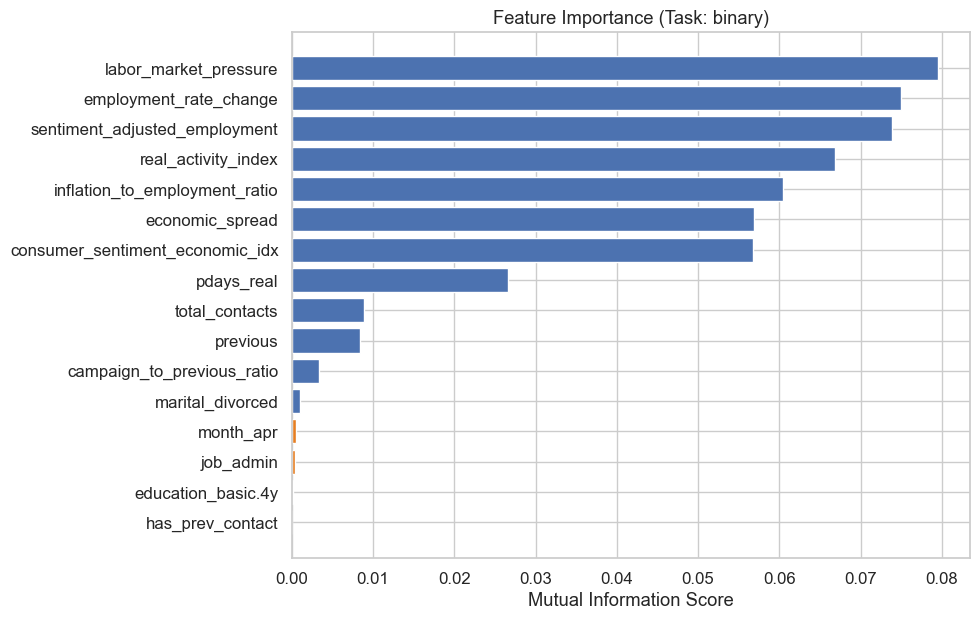

In [1175]:

TARGET_COL = 'y' 
RANDOM_STATE = 42

df = train_df.copy()

all_month_cols = [c for c in df.columns if c.startswith('month_') and c != 'month_apr']
df['month_apr'] = (df[all_month_cols].sum(axis=1) == 0).astype(int)

job_cols = [c for c in df.columns if c.startswith('job_') and c != 'job_admin']
df['job_admin'] = (df[job_cols].sum(axis=1) == 0).astype(int)

X_num = df.select_dtypes(include=['number']).drop(columns=[TARGET_COL], errors='ignore')
y = df[TARGET_COL]

mask_valid = (~y.isna()) & (~X_num.isna().any(axis=1))
y = y.loc[mask_valid]
X_num = X_num.loc[mask_valid]

def infer_task_type(y_series, max_unique_for_class=20):
    unique_vals = pd.unique(y_series.dropna())
    if y_series.dtype.kind in 'biu' and len(unique_vals) == 2:
        return 'binary'
    if np.issubdtype(y_series.dtype, np.number):
        if len(unique_vals) <= max_unique_for_class:
            return 'multiclass'
        return 'regression'
    return 'multiclass'

task_type = infer_task_type(y)
print(f"Detected task: {task_type}")

if task_type in ['binary', 'multiclass'] and not np.issubdtype(y.dtype, np.number):
    le = LabelEncoder()
    y_enc = pd.Series(le.fit_transform(y), index=y.index, name=TARGET_COL)
else:
    y_enc = y

if task_type in ['binary', 'multiclass']:
    y_enc = y_enc.astype(int)


results = []

if task_type in ['binary', 'multiclass']:
    discrete_mask = [X_num[col].nunique() < 15 for col in X_num.columns]
    
    mi_scores = mutual_info_classif(X_num, y_enc, random_state=RANDOM_STATE, discrete_features=discrete_mask)
    for feat, mi in zip(X_num.columns, mi_scores):
        results.append({'feature': feat, 'metric': 'MI', 'score': mi})

elif task_type == 'regression':
    pearson = X_num.apply(lambda s: s.corr(y_enc), axis=0)
    spearman_vals = []
    for col in X_num.columns:
        try:
            rho, _ = spearmanr(X_num[col], y_enc, nan_policy='omit')
        except:
            rho = np.nan
        spearman_vals.append(rho)
    spearman = pd.Series(spearman_vals, index=X_num.columns)

    for feat in X_num.columns:
        results.append({'feature': feat, 'metric': 'Pearson', 'score': pearson[feat]})
        results.append({'feature': feat, 'metric': 'Spearman', 'score': spearman[feat]})


res_df = pd.DataFrame(results)

def summarize_scores(res_df, task_type):
    pivot = res_df.pivot(index='feature', columns='metric', values='score')
    if task_type == 'regression':
        pivot['strength'] = pivot[['Pearson', 'Spearman']].abs().max(axis=1)
    else:
        pivot['strength'] = pivot['MI']
    return pivot.sort_values('strength', ascending=False)

ranked = summarize_scores(res_df, task_type)
print("\nTop 10 Ranked Features (including engineered features):")
print(ranked.head(10))

# رسم نمودار
plt.figure(figsize=(10, max(5, 0.4 * len(ranked))))
plot_df = ranked.sort_values('strength', ascending=True)

if task_type == 'regression':
    y_ticks = plot_df.index
    plt.barh(y_ticks, plot_df['strength'], color='#4c72b0', alpha=0.4, label='Max Abs Corr')
    plt.scatter(plot_df['Pearson'].abs(), y_ticks, color='#dd8452', label='|Pearson|', zorder=3)
    plt.scatter(plot_df['Spearman'].abs(), y_ticks, color='#55a868', label='|Spearman|', zorder=3)
    plt.xlabel('Association strength')
    plt.legend()
else:
    colors = ['#e67e22' if 'age_group' in i or 'month_' in i or 'job_' in i else '#4c72b0' for i in plot_df.index]
    plt.barh(plot_df.index, plot_df['strength'], color=colors)
    plt.xlabel('Mutual Information Score')

plt.title(f'Feature Importance (Task: {task_type})')
plt.tight_layout()
plt.show()
